In [15]:
import warnings
warnings.filterwarnings('ignore')

from flonacomldft.utils.io_utils import (
    get_project_path,
    load_csv_file,
    load_pickle_file,
)

from flonacomldft.utils.diagnostics import (
    Target_Log_Prob, 
    get_participation_ratio,
)

import torch
import numpy as np
import matplotlib.pyplot as plt

# from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

In [2]:
project_path = '/mnt/home/amolina/ceph/ADAPTIVE-DFT'

isms_files = ['1-adaptive/results_2/results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl', 
                '1-adaptive/results_2/results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl']

mlps_files = ['4-mlp-training/results_1/results_mlp_is0_25684204/is0_mlp_dic_training_25684204.pkl',
                '4-mlp-training/results_1/results_mlp_is1_256842010/is1_mlp_dic_training_256842010.pkl',]

In [3]:
adaptives_dic = [load_pickle_file('/'+ f, path=project_path) for f in isms_files]
mlps_dic = [load_pickle_file('/'+ f, path=project_path) for f in mlps_files]

In [17]:
path_fe = project_path + '/5-FE-comps/0-example'
mode_labels = [0, 1]

target_log_probs = [ Target_Log_Prob(energy_type='dft', 
                                    mode_label=mode_label, 
                                    mlp_model=mlps_dic[mode_label]['model'], 
                                    folder=path_fe).target_log_prob for mode_label in mode_labels ]

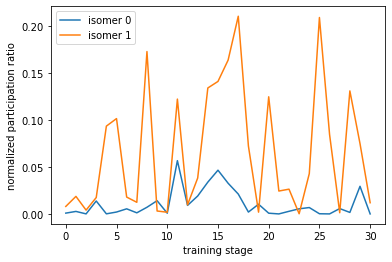

In [14]:
mode_labels = [0, 1]
n_prop = 10000
for mode_label in mode_labels:
    pprs = []
    for run in adaptives_dic[mode_label]['dict_flows_training']:
        flow = run[0]['models'][-1]
        ppr = get_participation_ratio(flow, target_log_probs[mode_label], n_prop)
        pprs.append(ppr.item())
    plt.plot(pprs, label='isomer {:d}'.format(mode_label))
plt.xlabel('training stage')
plt.ylabel('normalized participation ratio')
#plt.ylim(0, 0.5)
# plt.axhline(1, c='k', ls='--')
# plt.yscale('log')
plt.legend()

In [18]:
n_prop = 5

dic_results_TFPs = {}

for isomer_id in mode_labels:

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    plt.figure()
    plt.title('isomer {:d}'.format(isomer_id))
    for r,run in enumerate(adaptives_dic[isomer_id]['dict_flows_training']):
        flow = run[0]['models'][-1]
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(10):
            logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_probs[isomer_id], flow)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)
        
        dic_results_TFPs[isomer_id][r] = (log_ratio_0_TFPs, log_err_0_TFPs)
        
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*r, log_ratio_0_TFPs, marker='x', alpha=0.2)
        plt.scatter(r, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
    
    plt.errorbar(np.arange(len(dic_results_TFPs[isomer_id]['means'])), dic_results_TFPs[isomer_id]['means'], yerr=dic_results_TFPs[isomer_id]['stds'], fmt='o')
       

    plt.xlabel('adaptive mcmc retraining stage')
    plt.ylabel('log ratio by Targeted Free energy Perturbation (TFP)')

    # print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

: 

: 

: 